<a href="https://colab.research.google.com/github/jeremynwa/ecommerce_purchase_prediction/blob/main/ecommerce_purchase_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **M2 DSBA - Foundation of Machine Learning Challenge**

https://www.kaggle.com/competitions/m-2-dsba-foundation-of-machine-learning-challenge/overview

Tonghan Wen, Jeremy Garneau, Julien Dehut


# The datasets :
1. train_dataset.csv: This is the training dataset, containing user behavior data along with the target variable (Purchase), which indicates whether the user made a purchase.
2. eval_dataset.csv: This is the evaluation dataset, containing user behavior data for which you need to predict the Purchase outcome.

In [ ]:
#using this code you could connect to your google shared drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import packages

In [ ]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np
from numpy import mean
import xgboost as xgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier

##model importing
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA

#for cross validation
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV

from sklearn.metrics import make_scorer, f1_score,precision_score, recall_score
from scipy.stats import zscore

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import learning_curve

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
df_train=pd.read_csv('path/train_dataset.csv')

# **I) Data Exploration and Pre processing**

##**1. Understand the Problem and Data Collection**

- Define the Objective: Clearly understand the business problem or task you're trying to solve.
- Collect Data: Gather the dataset(s) from various sources, ensuring they are relevant to the problem.

##**2. Data Exploration (Exploratory Data Analysis - EDA)**

###**a. Understand the Structure of the Data**

- View the dataset
- Check data types (numerical, categorical, text, etc.).

In [ ]:
# Display the first few rows
df_train.head()

,id,Age,Gender,Reviews_Read,Price,Discount,Category,Items_In_Cart,Time_of_Day,Email_Interaction,Device_Type,Payment_Method,Referral_Source,Socioeconomic_Status_Score,Engagement_Score,Purchase
0,0,20.0,1.0,1.0,623.797,25.0,4.0,4.0,afternoon,0.0,Desktop,PayPal,Direct,9.13,2.167873,0
1,1,22.0,0.0,5.0,549.324,50.0,4.0,8.0,evening,0.0,Desktop,Bank,Search_engine,9.53,3.494243,0
2,2,18.0,0.0,2.0,489.191,19.0,0.0,5.0,afternoon,0.0,Mobile,Bank,Email,0.70,2.093568,0
3,3,25.0,0.0,3.0,769.450,16.0,4.0,5.0,evening,0.0,Mobile,Credit,Social_media,6.83,3.644859,0
4,4,22.0,1.0,2.0,39.308,35.0,0.0,3.0,evening,0.0,Mobile,NaN,Email,1.86,4.171256,0


In [ ]:
# Summary of data types and non-null values
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          6500 non-null   int64  
 1   Age                         5530 non-null   float64
 2   Gender                      6359 non-null   float64
 3   Reviews_Read                6373 non-null   float64
 4   Price                       6355 non-null   float64
 5   Discount                    6376 non-null   float64
 6   Category                    6366 non-null   float64
 7   Items_In_Cart               6359 non-null   float64
 8   Time_of_Day                 6371 non-null   object 
 9   Email_Interaction           6373 non-null   float64
 10  Device_Type                 6376 non-null   object 
 11  Payment_Method              5491 non-null   object 
 12  Referral_Source             5503 non-null   object 
 13  Socioeconomic_Status_Score  6380 

In [ ]:
# Summary statistics for numerical columns
df_train.describe()

,id,Age,Gender,Reviews_Read,Price,Discount,Category,Items_In_Cart,Email_Interaction,Socioeconomic_Status_Score,Engagement_Score,Purchase
count,6500.000000,5530.000000,6359.000000,6373.000000,6355.000000,6376.000000,6366.000000,6359.000000,6373.000000,6380.000000,6365.000000,6500.000000
mean,3249.500000,32.262387,0.655449,3.040169,503.130619,24.929893,1.986962,3.517691,0.335635,4.674003,2.241484,0.116308
std,1876.532707,13.139954,0.475259,1.750693,288.370017,14.363208,1.412986,2.905012,0.472249,3.468992,1.435611,0.320618
min,0.000000,18.000000,0.000000,0.000000,5.175000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1624.750000,22.000000,0.000000,2.000000,254.650000,13.000000,1.000000,1.000000,0.000000,2.140000,1.042197,0.000000
50%,3249.500000,28.000000,1.000000,3.000000,503.002000,25.000000,2.000000,3.000000,0.000000,3.840000,2.068211,0.000000
75%,4874.250000,39.000000,1.000000,4.000000,751.299500,37.000000,3.000000,5.000000,1.000000,6.572500,3.300755,0.000000
max,6499.000000,65.000000,1.000000,12.000000,999.901000,50.000000,4.000000,21.000000,1.000000,24.110000,6.398595,1.000000


In [ ]:
#Observe the target value
df_train['Purchase'].value_counts()

,count
Purchase,
0,5744
1,756


###**b. Identify Missing Data**

In [ ]:
# detecting missing values
df_train.isnull().sum()

,0
id,0
Age,970
Gender,141
Reviews_Read,127
Price,145
Discount,124
Category,134
Items_In_Cart,141
Time_of_Day,129
Email_Interaction,127


<Axes: >

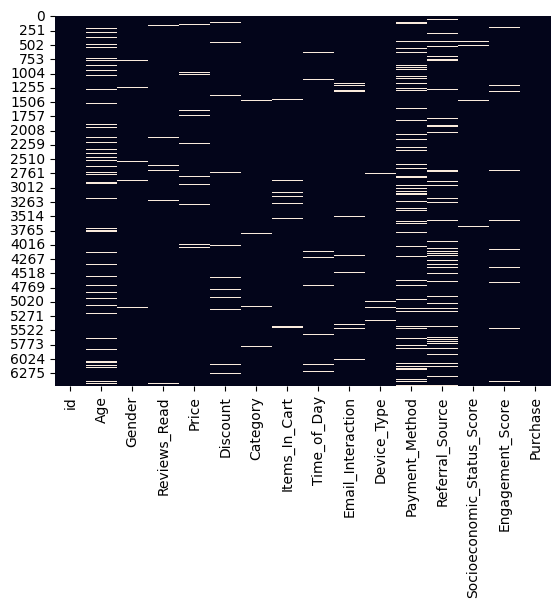

In [ ]:
#Visualize localization of missing data
sns.heatmap(df_train.isnull(), cbar=False)

###**c. Examine Data Distribution**

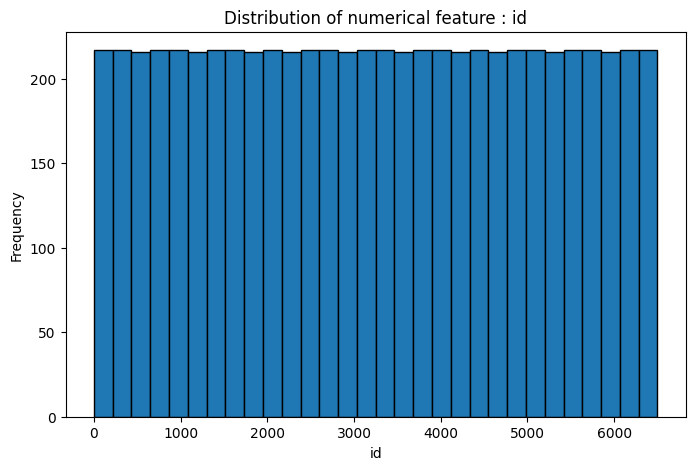

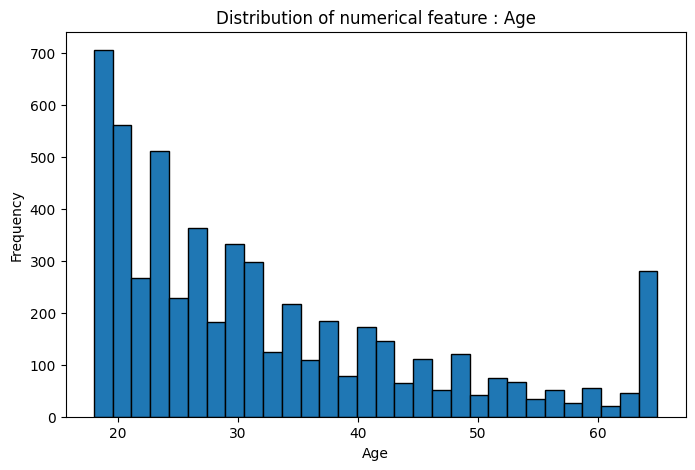

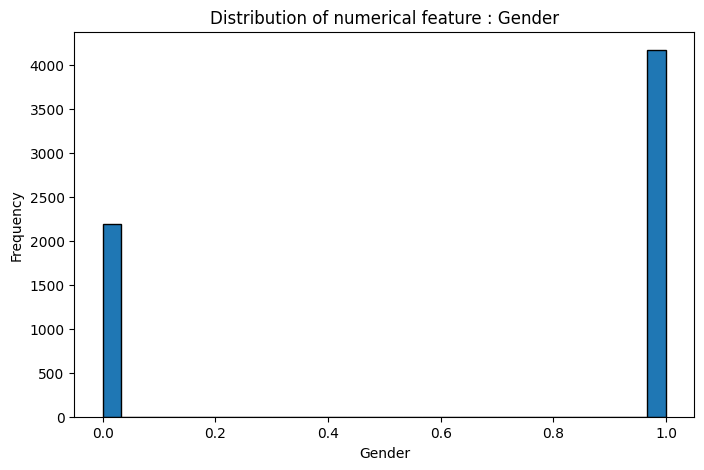

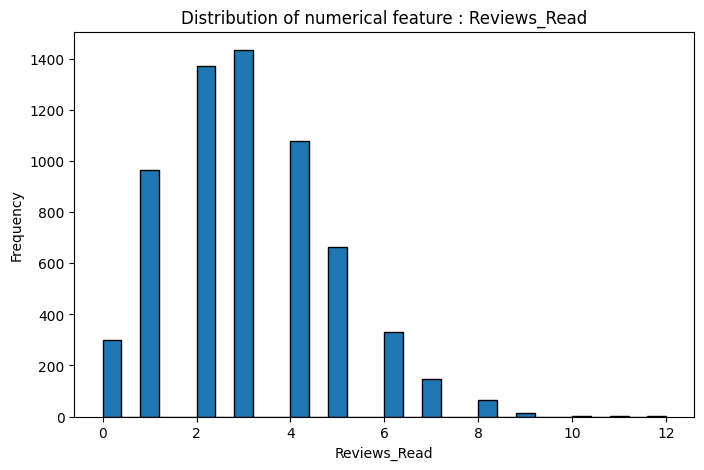

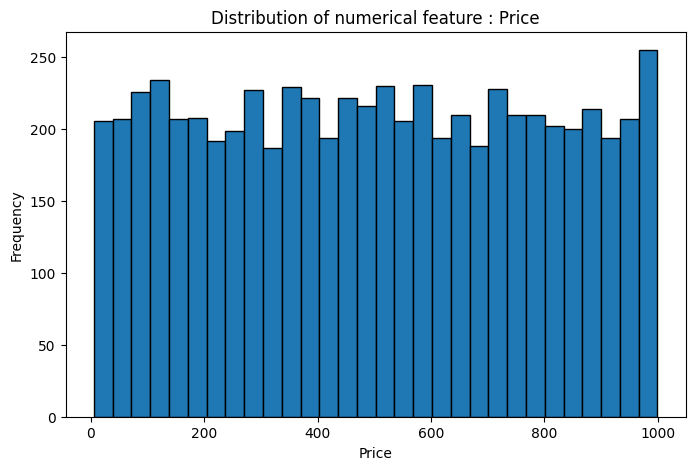

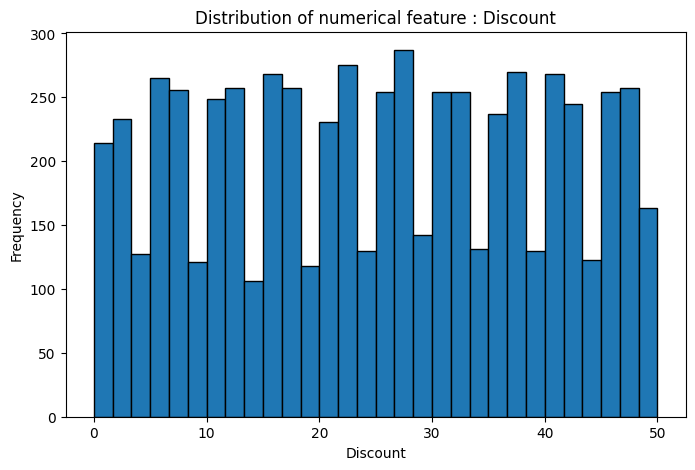

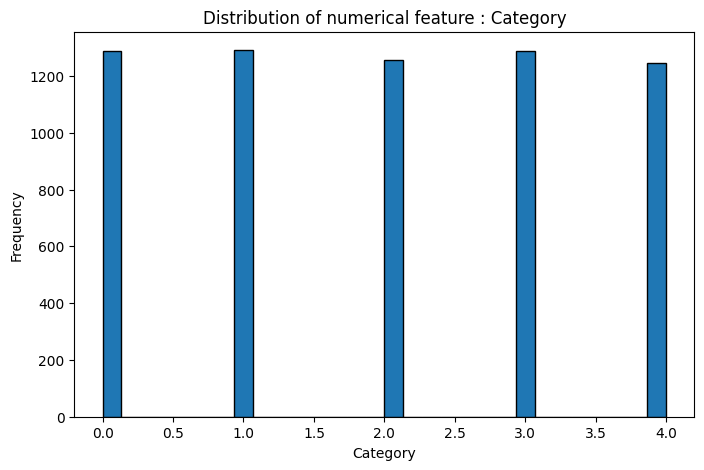

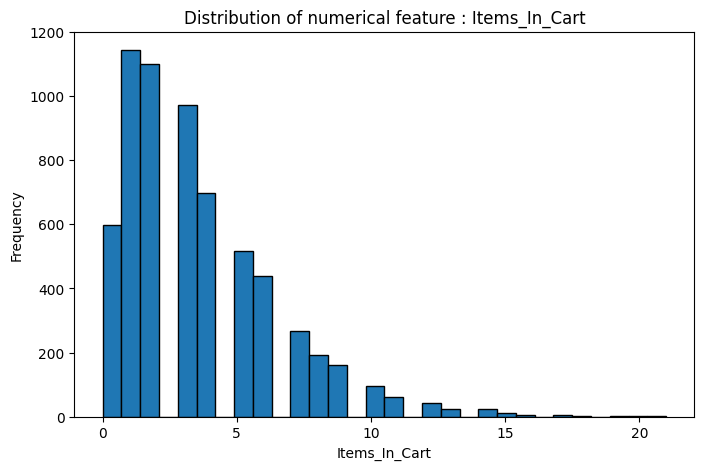

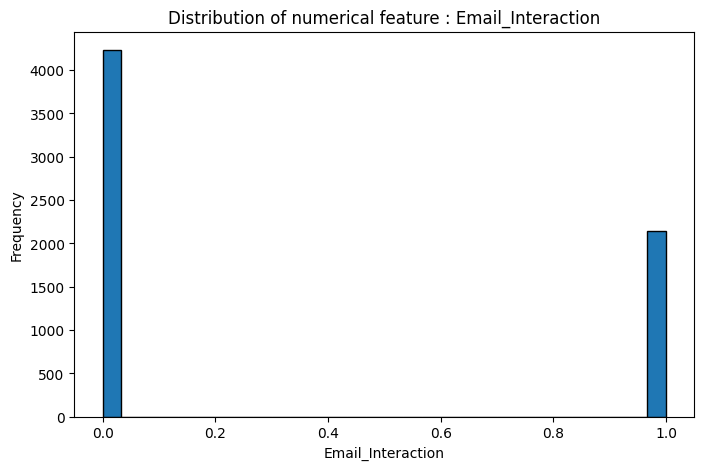

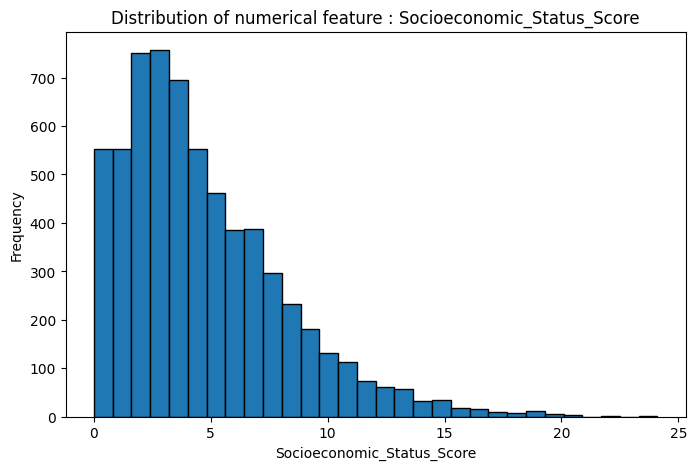

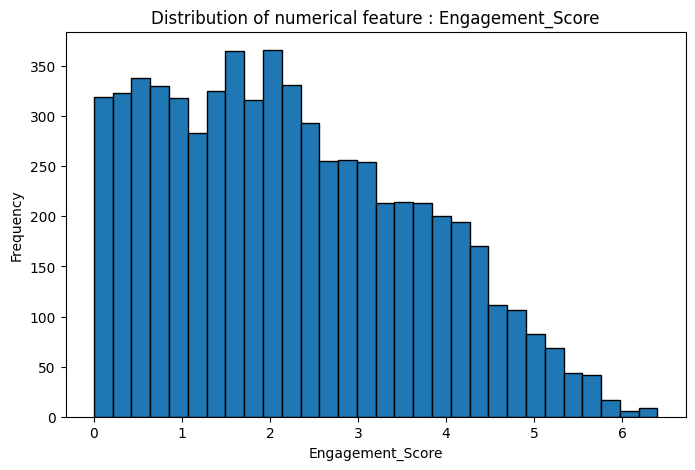

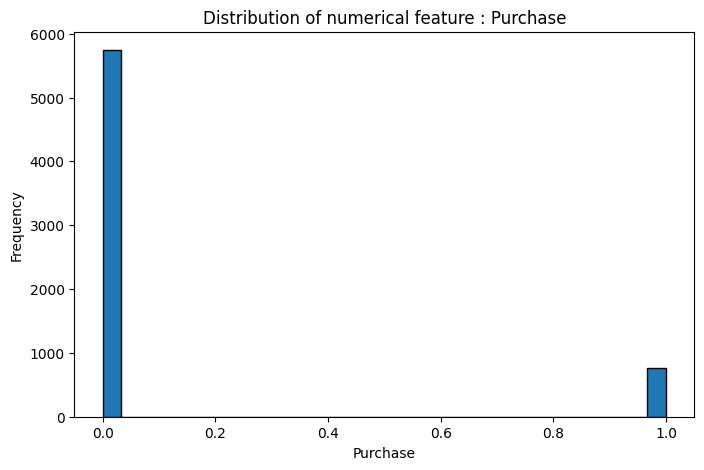

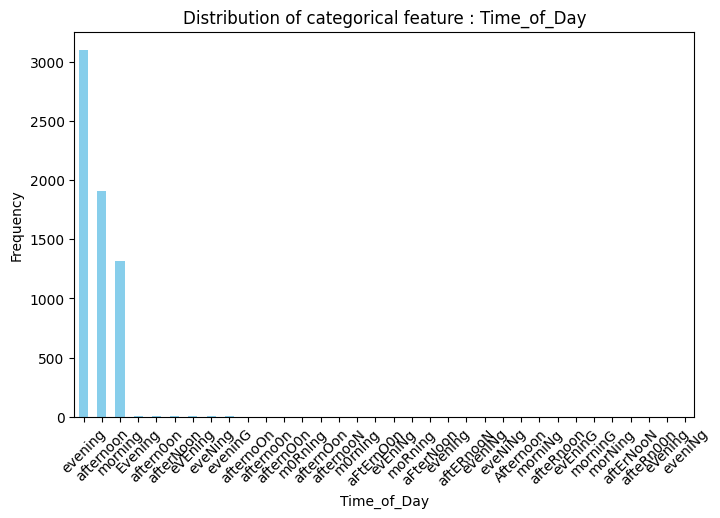

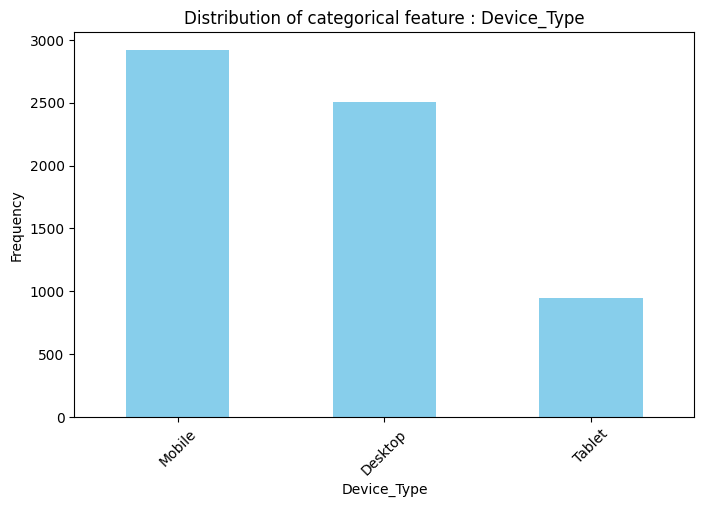

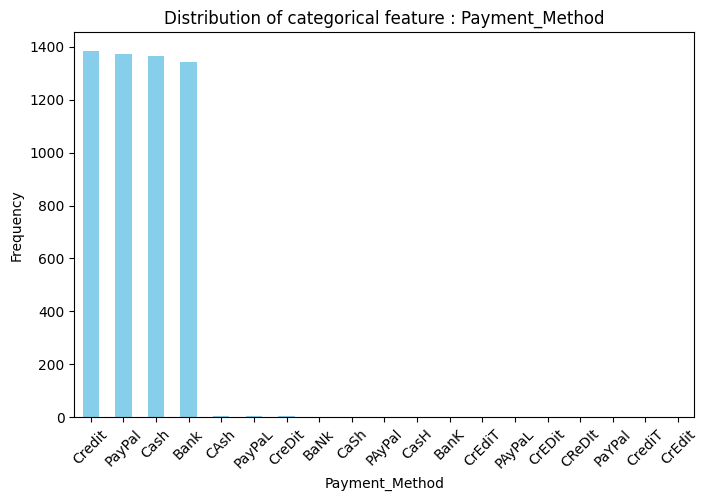

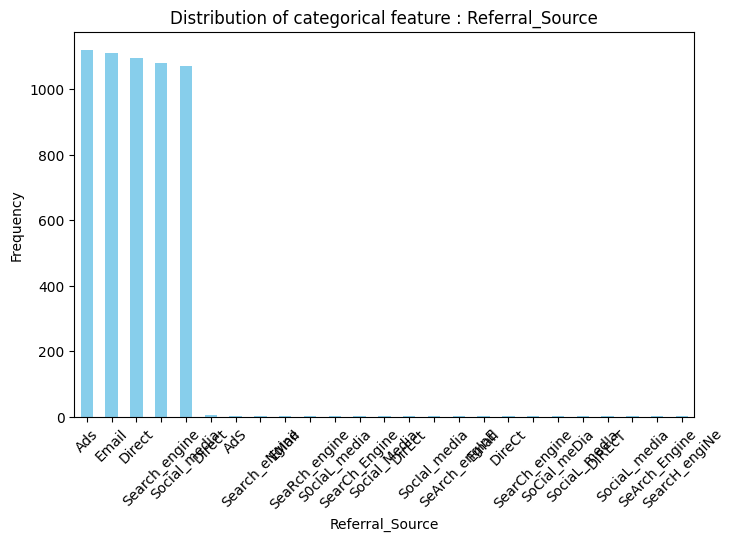

In [ ]:
# List of numerical data columns
numerical_features = df_train.select_dtypes(include=['float64', 'int64']).columns

# List of categorical data columns
categorical_features = df_train.select_dtypes(include=['object']).columns

# 1. Distribution numerical features
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    df_train[feature].hist(bins=30, edgecolor='black')
    plt.title(f'Distribution of numerical feature : {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(False)
    plt.show()

# 2. Distribution categorical features
for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    df_train[feature].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'Distribution of categorical feature : {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.grid(False)
    plt.show()

###**d. Check Correlations**

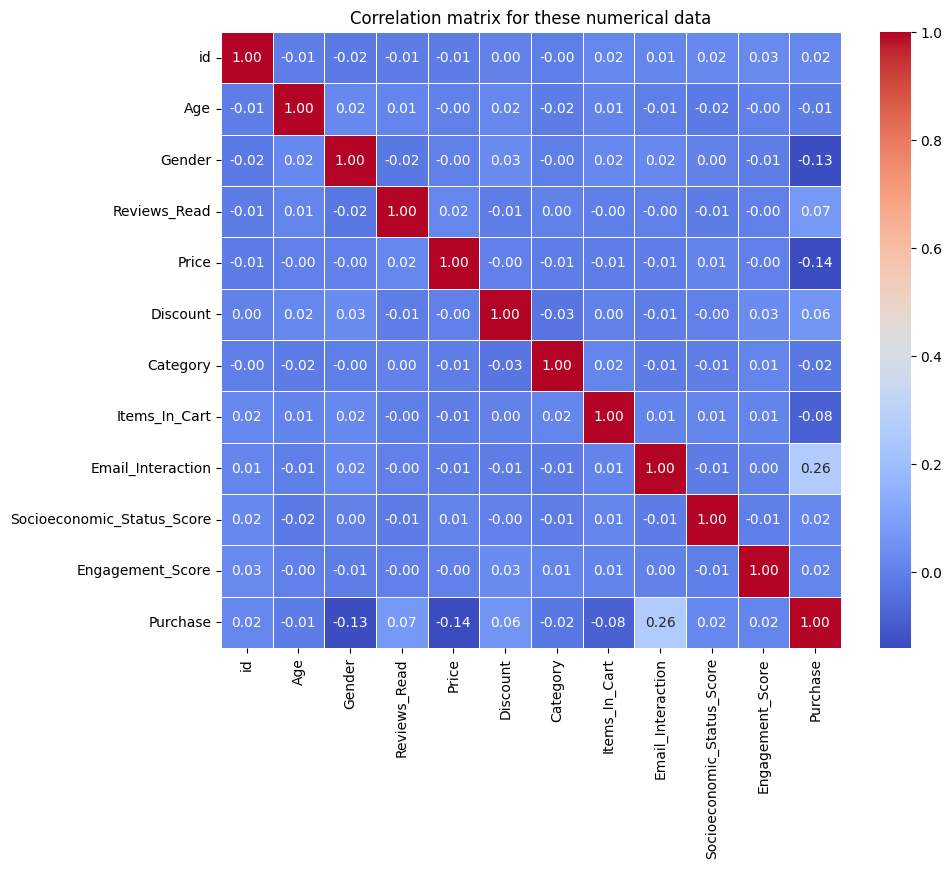

In [ ]:
#Identify relationships between numerical features using a correlation matrix

# Select just the numerical data columns
numerical_features_data = df_train.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix for these numerical data
corr_matrix = numerical_features_data.corr()

# Print the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation matrix for these numerical data')
plt.show()

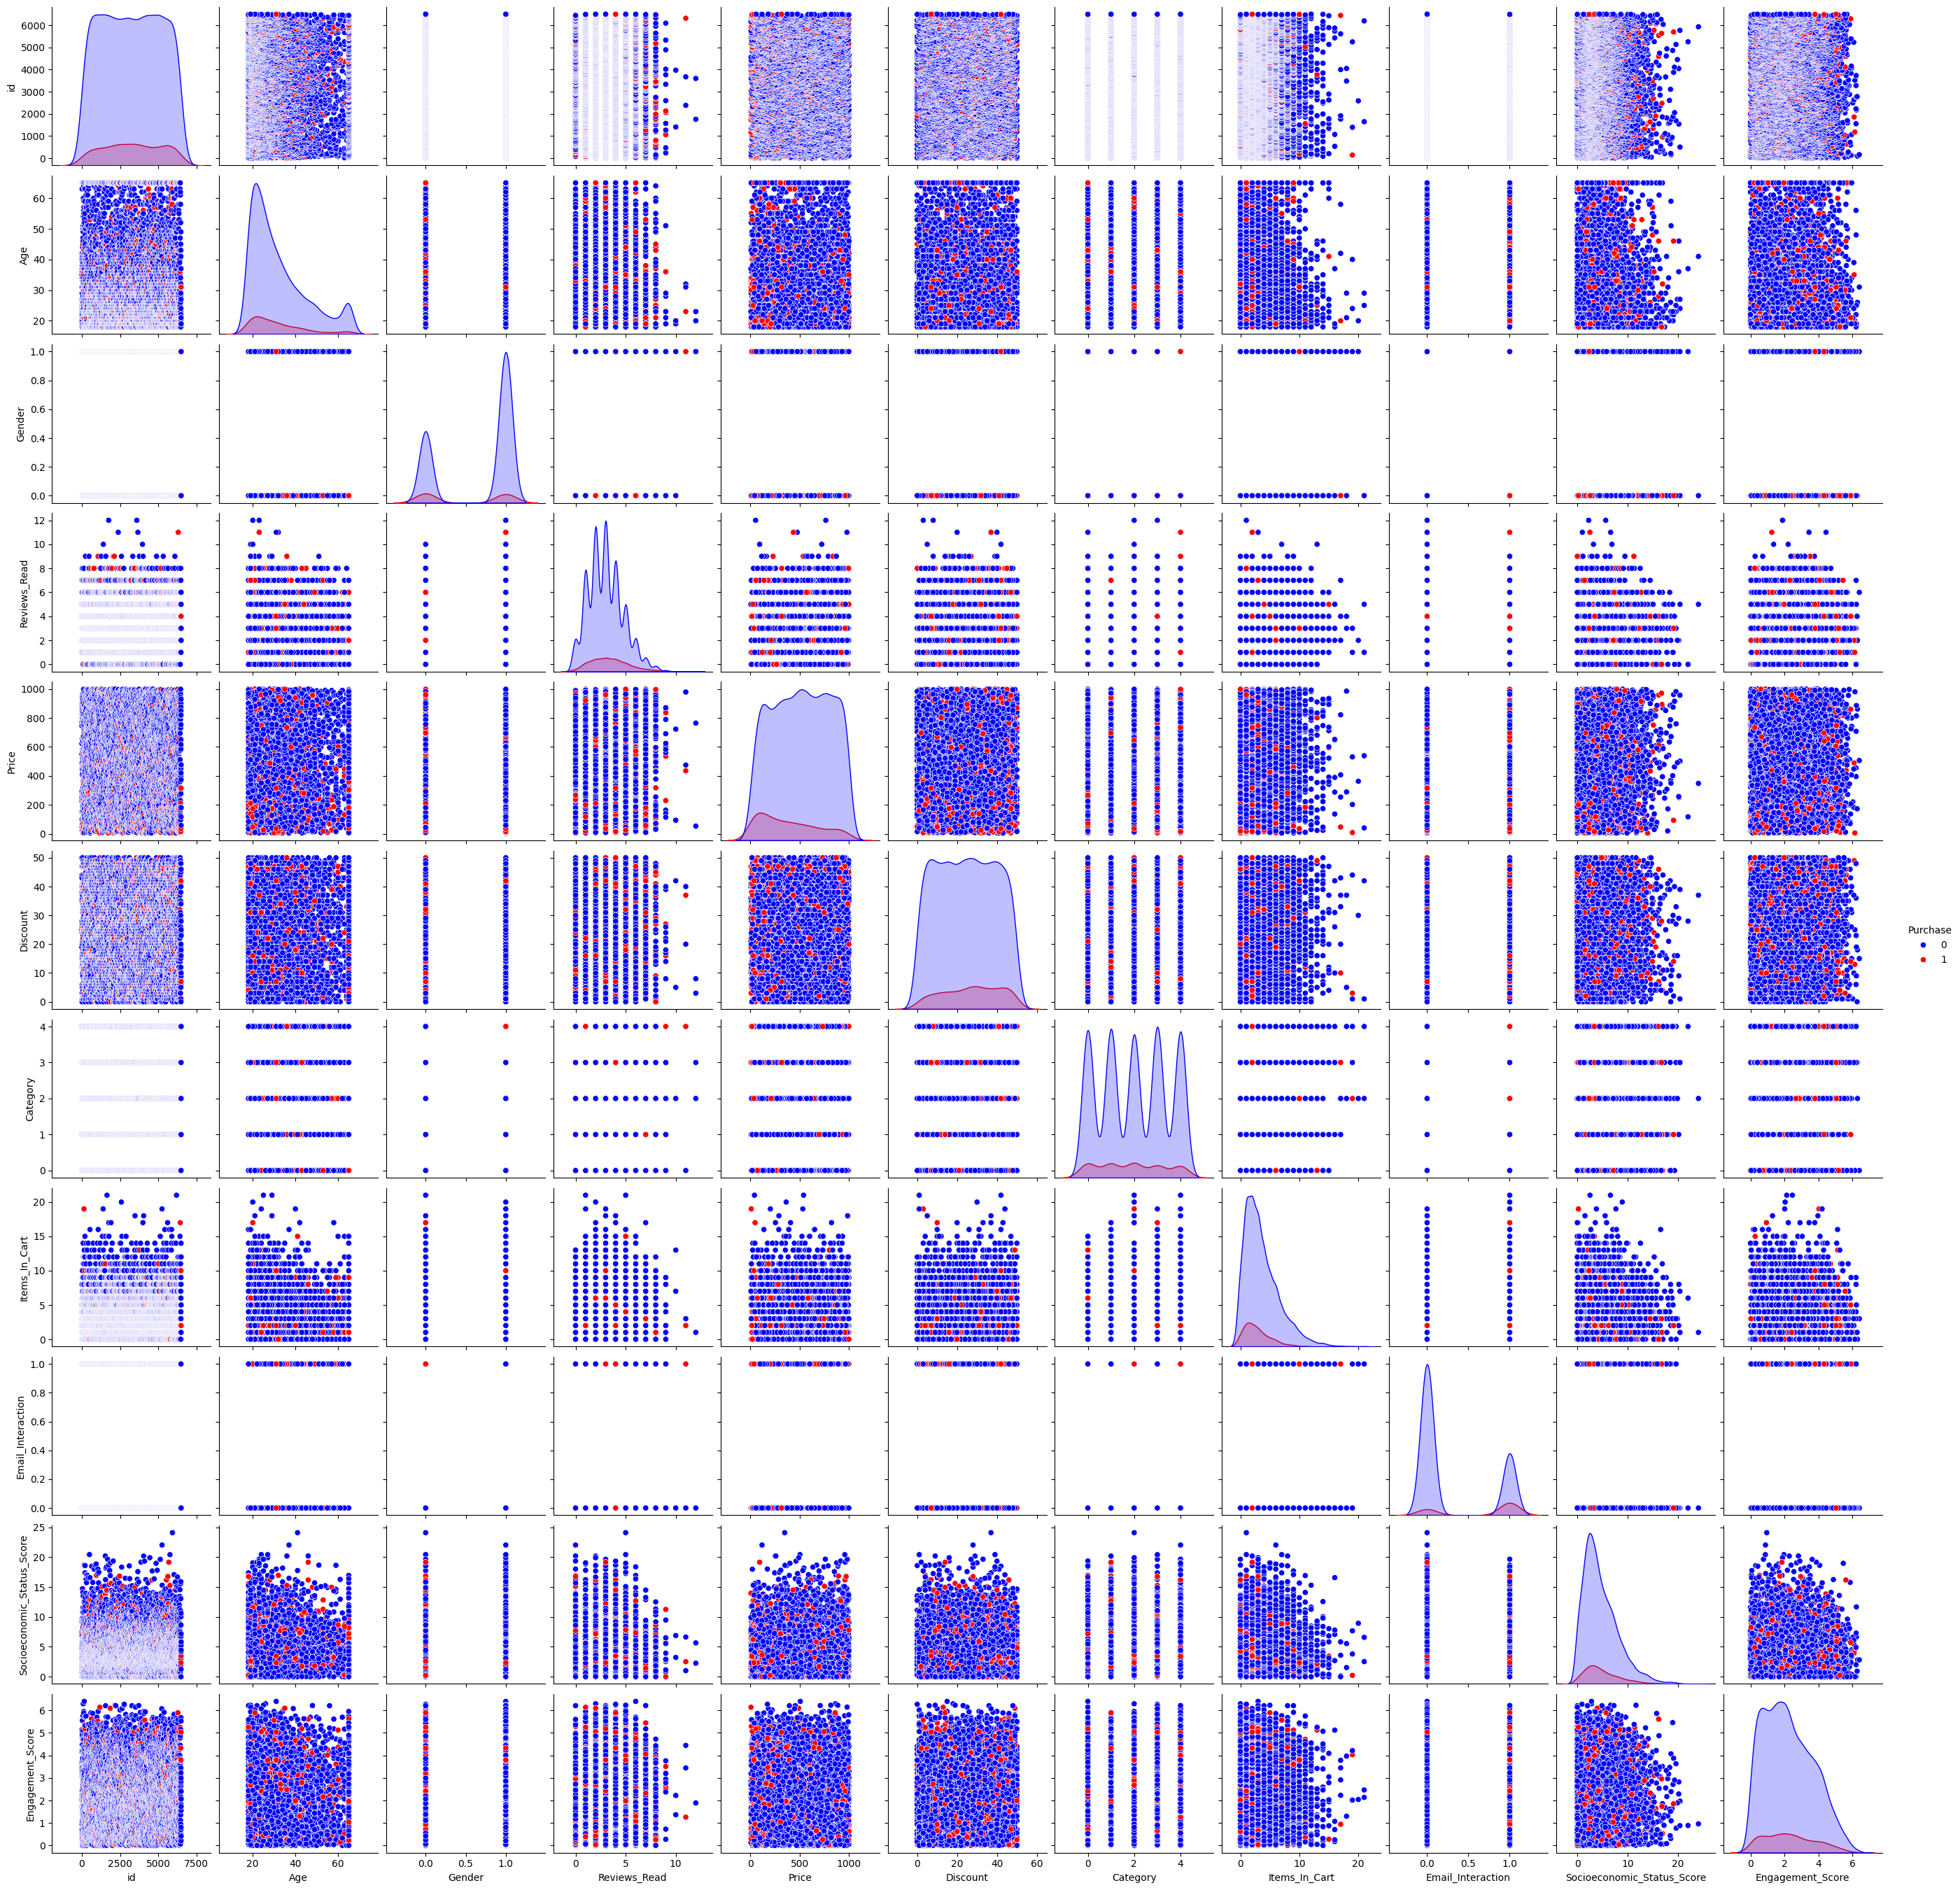

In [ ]:
#visualization to try to detect trends or groups
sns.pairplot(
    df_train,
    #vars=['id', 'Age', 'Gender', 'Reviews_Read', 'Price','Discount','Category','Items_In_Cart', 'Time_of_Day', 'Email_Interaction','Device_Type', 'Payment_Method','Referral_Source', 'Socioeconomic_Status_Score', 'Engagement_Score'],
    vars=['id', 'Age', 'Gender', 'Reviews_Read', 'Price','Discount','Category','Items_In_Cart', 'Email_Interaction', 'Socioeconomic_Status_Score', 'Engagement_Score'],
    hue='Purchase',
    palette={0: 'blue', 1: 'red'},
    diag_kind='kde'  # KDE plots on the diagonal
)
plt.show()

##**3. Data Cleaning**

###**a. Remove Duplicates**
Remove any duplicate rows from the dataset to avoid bias in training.

In [ ]:
df_train.duplicated().sum()
#so we could see there is no doublons in this dataset

0

###**b. Handle Missing Values**
First, we will check for missing values and handle them appropriately. This can include removing missing values or imputing them.

In [ ]:
#1. Check for Missing Values in each column
df_train.isnull().sum()

,0
id,0
Age,970
Gender,141
Reviews_Read,127
Price,145
Discount,124
Category,134
Items_In_Cart,141
Time_of_Day,129
Email_Interaction,127


In [ ]:
#We drop the column payment_method because this column has so many missing value>1/6
df_train_clean=df_train.drop(columns=['Payment_Method','Age'])

#drop the column which dont have a significant impact on result
df_train_clean=df_train_clean.drop(columns=['id'])

choose one technique or the other to replace numeric values

In [ ]:
# Replace missing values in numeric columns with the mean
numeric_columns = ['Price','Discount','Socioeconomic_Status_Score','Engagement_Score']
df_train_clean[numeric_columns] = df_train_clean[numeric_columns].apply(lambda col: col.fillna(col.mean()))

We've tried KNN but it doesnt work well, so finally we decided to erase it

In [ ]:
# Replace missing values in categorical columns with the mode
categorical_columns = ['Reviews_Read','Items_In_Cart', 'Device_Type', 'Gender','Category','Email_Interaction', 'Time_of_Day','Referral_Source']
df_train_clean[categorical_columns] = df_train_clean[categorical_columns].apply(lambda col: col.fillna(col.mode()[0]))

In [ ]:
#check the result
df_train_clean.isnull().sum()

,0
Gender,0
Reviews_Read,0
Price,0
Discount,0
Category,0
Items_In_Cart,0
Time_of_Day,0
Email_Interaction,0
Device_Type,0
Referral_Source,0


###**d. Correct Inconsistent Data**
Ensure that the data is formatted consistently.

In [ ]:
#Start by looking in some columns the distinct values, the goal is to detect the type of errors we can have
#and the class of the values
for col in df_train_clean.columns:
    print(f"Column: {col}")                                          # Print the column name
    print(f"Unique values: {df_train_clean[col].unique()}")                # Print unique values in the column
    print(f"Type of unique values: {type(df_train_clean[col].unique())}")  # Print the type of the unique values
    print("-" * 50)                                                  # Separator for better readability

Column: Gender
Unique values: [1. 0.]
Type of unique values: <class 'numpy.ndarray'>
--------------------------------------------------
Column: Reviews_Read
Unique values: [ 1.  5.  2.  3.  6.  4.  7.  8.  0.  9. 10. 12. 11.]
Type of unique values: <class 'numpy.ndarray'>
--------------------------------------------------
Column: Price
Unique values: [623.797 549.324 489.191 ... 373.853 476.629 180.914]
Type of unique values: <class 'numpy.ndarray'>
--------------------------------------------------
Column: Discount
Unique values: [25.         50.         19.         16.         35.         37.
 44.         38.         28.         15.         47.         43.
  5.         24.          0.         40.          1.         26.
 12.         17.          3.         21.         36.         24.92989335
 41.         10.          6.         13.         20.         34.
 27.         14.         39.         31.         32.          2.
  9.         23.          4.         48.         22.         29.


In [ ]:
def clean_column(word):
  if word is not None:
      word=str(word).lower().replace('0','o')
  return word

In [ ]:
df_train_clean['Time_of_Day']=df_train_clean['Time_of_Day'].map(lambda x:clean_column(x) if pd.notnull(x) else x)

df_train_clean['Referral_Source']=df_train_clean['Referral_Source'].map(lambda x:clean_column(x) if pd.notnull(x) else x)

In [ ]:
#check the result
for col in df_train_clean.columns:
    print(f"Column: {col}")                                          # Print the column name
    print(f"Unique values: {df_train_clean[col].unique()}")                # Print unique values in the column
    print(f"Type of unique values: {type(df_train_clean[col].unique())}")  # Print the type of the unique values
    print("-" * 50)

Column: Gender
Unique values: [1. 0.]
Type of unique values: <class 'numpy.ndarray'>
--------------------------------------------------
Column: Reviews_Read
Unique values: [ 1.  5.  2.  3.  6.  4.  7.  8.  0.  9. 10. 12. 11.]
Type of unique values: <class 'numpy.ndarray'>
--------------------------------------------------
Column: Price
Unique values: [623.797 549.324 489.191 ... 373.853 476.629 180.914]
Type of unique values: <class 'numpy.ndarray'>
--------------------------------------------------
Column: Discount
Unique values: [25.         50.         19.         16.         35.         37.
 44.         38.         28.         15.         47.         43.
  5.         24.          0.         40.          1.         26.
 12.         17.          3.         21.         36.         24.92989335
 41.         10.          6.         13.         20.         34.
 27.         14.         39.         31.         32.          2.
  9.         23.          4.         48.         22.         29.


###**c. Handle Outliers**
We've tried to identify and delete the outliers using the z-score. However, the performance of model get worse, which indicates that the outlier may contain important information for target value. In this case, we decided to keep outlier and then remove this part

##**4. Feature Engineering**

### **a. Encoding the categorical data**
- Time_of_Day --> label-encoding
(maybe in the evening the customer would be likely to make the purchase, so I use label-encoding
- Payment_Method --> label-encoding
- Referral_Source--> label-encoding

- Device_Type --> label-encoding


In [ ]:
df1 = df_train_clean

In [ ]:
#personize the encoding based on the correlation
df1['Time_of_Day']=df1['Time_of_Day'].replace({'evening':1,'afternoon':0,'morning':0})
df1['Referral_Source']=df1['Referral_Source'].replace({'search_engine':1,'direct':1,'social_media':0,'email':0,'ads':0})
df1['Device_Type']=df1['Device_Type'].replace({'Mobile':2,'Desktop':1,'Tablet':0})

<ipython-input-386-71a6b9fd8a60>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['Time_of_Day']=df1['Time_of_Day'].replace({'evening':1,'afternoon':0,'morning':0})
<ipython-input-386-71a6b9fd8a60>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['Referral_Source']=df1['Referral_Source'].replace({'search_engine':1,'direct':1,'social_media':0,'email':0,'ads':0})
<ipython-input-386-71a6b9fd8a60>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavi

### **b. Standardize Numerical Columns**

This worked to improve some classifiers such as Gradient Boosting, but did not improve our best model, XGBoost.

### **c. Feature Creation/Selection and Dimension Reduction**

trials of different features but didn't improve the model

In [ ]:
# #1. Interaction features

# #Engagement with Discounts:
# #High engagement and large discounts might indicate a higher likelihood of purchase
# df1['Engagement_Discount'] = df1['Engagement_Score'] * df1['Discount']

# #Price-Adjusted Discount:
# #The absolute value of the discount based on the item's price.
# df1['Price_Adjusted_Discount'] = df1['Price'] * (df1['Discount'] / 100)

# #Socioeconomic Influence on Purchase:
# #Wealthier customers might have different purchasing behaviors.
# df1['Socioeconomic_Purchase'] = df1['Socioeconomic_Status_Score'] * df1['Price']

In [ ]:
# #2. Aggregation Features

# #Average Discount in Category:
# #Helps identify categories with frequent discounts.
# df1['Avg_Discount_Category'] = df1.groupby('Category')['Discount'].transform('mean')

# #Reviews Per Item in Cart:
# #Avoids division by zero and reflects the effort spent reviewing each item.
# df1['Reviews_Per_Item'] = df1['Reviews_Read'] / (df1['Items_In_Cart'] + 1)

# #Socioeconomic to Engagement Ratio:
# #Indicates how socioeconomic status aligns with engagement.
# df1['Socioeconomic_Engagement_Ratio'] = df1['Socioeconomic_Status_Score'] / (df1['Engagement_Score'] + 1)

In [ ]:
# #3. Behavioral Features

# #Cart Engagement:
# #High engagement but few items in the cart might indicate selective interest.
# df1['Engagement_Per_Item'] = df1['Engagement_Score'] / (df1['Items_In_Cart'] + 1)

# #Price per Item in Cart:
# #Helps distinguish bulk buyers from high-value item purchasers.
# df1['Price_Per_Item'] = df1['Price'] / (df1['Items_In_Cart'] + 1)

# #Referral Category Impact:
# #Indicates if referrals work more for some products. Also tries to relate two features that have low impact.
# df1['Referral_Category_Impact'] = df1['Referral_Source'] * df1['Category']

Selected Features

In [ ]:
df1['engagement'] = (
    0.7 * df1['Email_Interaction'] +  0.2 * df1['Engagement_Score'] / df1['Engagement_Score'].max() +0.1 * df1['Device_Type']  # Lower weight for device usage
)

In [ ]:
def categorize_reviews(value):
    if value <= 1:
        return 0
    elif 2 <= value <= 4:
        return 1
    elif 5 <= value <= 6:
        return 2
    else:
        return 3

# Apply categorization
df1['Reviews_Read'] = df1['Reviews_Read'].apply(categorize_reviews)

In [ ]:
def categorize_items(value):
    if value <= 2:
        return 3
    elif 3 <= value <= 6:
        return 2
    elif 7 <= value <= 10:
        return 1
    else:
        return 0

# Apply categorization
df1['Items_In_Cart'] = df1['Items_In_Cart'].apply(categorize_items)

In [ ]:
#Column Deleting Part
df1=df1.drop(columns=['Device_Type','Email_Interaction','Engagement_Score'])

In [ ]:
df_corr=df1.corr()
df_corr['Purchase']

,Purchase
Gender,-0.128083
Reviews_Read,0.062503
Price,-0.138535
Discount,0.057186
Category,-0.025530
Items_In_Cart,0.079901
Time_of_Day,0.052273
Referral_Source,0.000291
Socioeconomic_Status_Score,0.022806
Purchase,1.000000


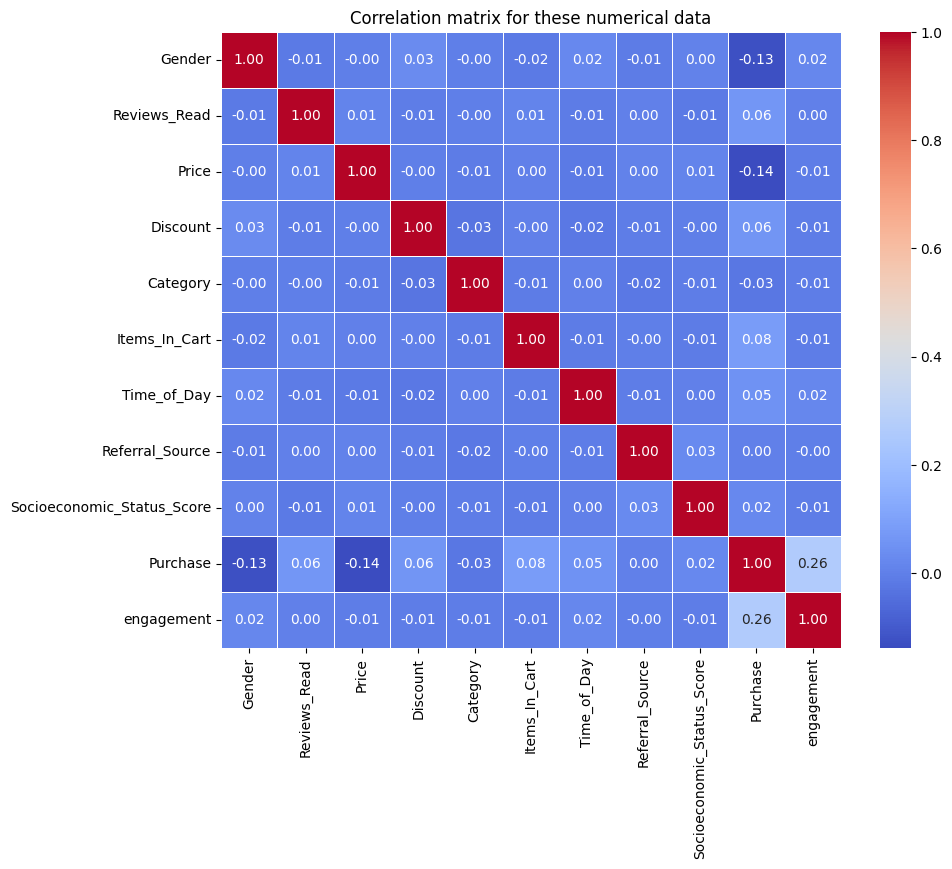

In [ ]:
# Select just the numerical data columns
numerical_features_data = df1.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix for these numerical data
corr_matrix = numerical_features_data.corr()

# Print the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation matrix for these numerical data')
plt.show()

# **II) Data Splitting and Oversampling**

### **1. Visualization of imbalance data**

/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


<Axes: xlabel='Purchase', ylabel='count'>

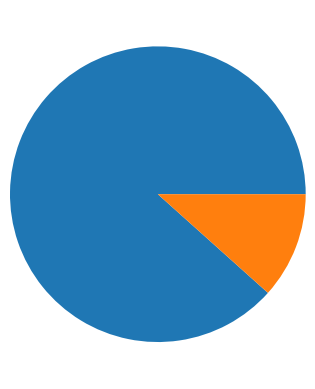

In [ ]:
df_train_clean = df1
df_train_clean.head()
data_imbalanced=df_train_clean['Purchase'].value_counts()
plt.pie(data_imbalanced)
data_imbalanced2=df_train_clean[['Purchase']]
sns.countplot(data=data_imbalanced2,x='Purchase')
#plt.pie(data_imbalanced2, labels=data_imbalanced2.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'orange'])

###**2. Split the Data into Train and Test**

In [ ]:
X=df1.drop(columns=['Purchase'])
y=df1['Purchase']

###**3. OverSampling**

Original dataset shape: Counter({0: 5744, 1: 756})
Resampled dataset shape: Counter({0: 5744, 1: 5744})


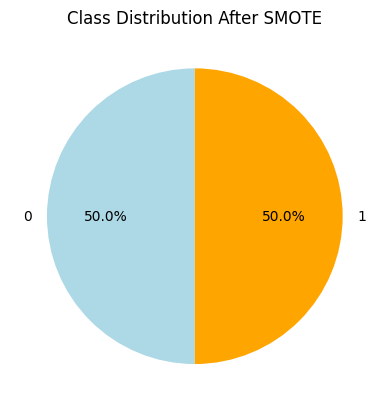

In [ ]:
# SMOTE
smote = SMOTE(random_state=42)
x_ros, y_ros = smote.fit_resample(X, y)

# Check the class distribution after SMOTE
print('Original dataset shape:', Counter(y))
print('Resampled dataset shape:', Counter(y_ros))

# Visualize the balanced dataset
df_imbalanced = y_ros.value_counts()
plt.pie(df_imbalanced, labels=df_imbalanced.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'orange'])
plt.title('Class Distribution After SMOTE')
plt.show()

#**III) Models**

## **1. LightGBM**

In [ ]:
lgbm = LGBMClassifier(random_state=42, verbose=-1)  # Suppress logs

param_grid = {
    'learning_rate': [0.2, 0.3, 0.4],
    'max_depth': [2,5],
    'n_estimators': [100],
    'min_child_weight': [5],
    'gamma': [1],
    'reg_lambda': [1],
    'reg_alpha': [1]
}

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=1
)
grid_search.fit(x_ros, y_ros)

# Get the best parameters and best model
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.2f}")
best_model_lgbm = grid_search.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters: {'gamma': 1, 'learning_rate': 0.4, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 1}
Best Cross-Validation Score: 0.88


In [ ]:
best_model_lgbm = LGBMClassifier(random_state=42, gamma = 1, learning_rate = 0.4, max_depth = 2, min_child_weight = 5, n_estimators = 100, reg_alpha= 1, reg_lambda= 1)

In [ ]:
best_model_lgbm.fit(x_ros, y_ros)

LGBMClassifier(gamma=1, learning_rate=0.4, max_depth=2, min_child_weight=5,
               random_state=42, reg_alpha=1, reg_lambda=1)

## **2. Random Forest**

In [ ]:
# Initialize RF model
model = RandomForestClassifier(random_state=42, n_estimators=100)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2,4,7,15],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1',  # Metric to optimize
    cv=5,                # Number of folds
    verbose=1             #Verbosity of printing messages. Valid values of 0 (silent), 1 (warning), 2 (info), and 3 (debug)
)

# Perform grid search
grid_search.fit(x_ros, y_ros)

# Display the best parameters and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.2f}")


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross-Validation Score: 0.87


In [ ]:
best_model_RF = RandomForestClassifier(bootstrap = True, max_depth = 2, max_features= 'sqrt', min_samples_leaf= 1, min_samples_split= 2, n_estimators= 200)

In [ ]:
best_model_RF.fit(x_ros, y_ros)

RandomForestClassifier(max_depth=2, n_estimators=200)

## **3. C5 Tree**

C5.0 is a decision tree algorithm that is widely used in supervised learning. It is an updated version of the ID3 algorithm and is known for its high accuracy and performance.

C5.0 builds decision trees by selecting features that maximally differentiate between classes using information gain and gain ratio measures. It also incorporates pruning methods to prevent overfitting and improve generalization performance.

In [ ]:
# Initialize XGBoost model
model = DecisionTreeClassifier()

# Define hyperparameter grid
param_grid = {
    'max_depth':[2,3,5,7,11,13],           # Limit the maximum depth
    'min_samples_leaf':[1,5,7,9,11,13],    # Minimum samples per leaf
    'min_samples_split':[2,5,7,9,11,13],  # Minimum samples required to split a node
    'ccp_alpha':[0.001,0.01,0.05,0.1]}



# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1',  # Metric to optimize
    cv=5,                # Number of folds
    verbose=1             #Verbosity of printing messages. Valid values of 0 (silent), 1 (warning), 2 (info), and 3 (debug)
)

# Perform grid search
grid_search.fit(x_ros, y_ros)

# Display the best parameters and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.2f}")

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Best Parameters: {'ccp_alpha': 0.001, 'max_depth': 13, 'min_samples_leaf': 7, 'min_samples_split': 2}
Best Cross-Validation Score: 0.77


In [ ]:
best_c5_clf = DecisionTreeClassifier(criterion='entropy', ccp_alpha= 0.001, max_depth=2, min_samples_leaf= 7, min_samples_split=2)

In [ ]:
best_c5_clf.fit(x_ros,y_ros)

DecisionTreeClassifier(ccp_alpha=0.001, criterion='entropy', max_depth=2,
                       min_samples_leaf=7)

## **4. XG-Boost**

In [ ]:
# Initialize XGBoost model
model = XGBClassifier(random_state=42,alpha=1.0, # L1 regularization
    reg_lambda=1.0)

# Define hyperparameter grid
param_grid = {
    'learning_rate': [0.01, 0.015, 0.05, 0.17],
    'max_depth': [3, 5, 7,11],
    'n_estimators': [50, 100, 125],
    'gamma':[0,0.1,0.3,0.7],
    'reg_lambda':[0, 0.1, 0.5, 1]
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1',  # Metric to optimize
    cv=5,                # Number of folds
    verbose=1             #Verbosity of printing messages. Valid values of 0 (silent), 1 (warning), 2 (info), and 3 (debug)
)

# Perform grid search
grid_search.fit(x_ros, y_ros)

# Display the best parameters and score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.2f}")

Fitting 5 folds for each of 768 candidates, totalling 3840 fits
Best Parameters: {'gamma': 0, 'learning_rate': 0.17, 'max_depth': 11, 'n_estimators': 125, 'reg_lambda': 0}
Best Cross-Validation Score: 0.96


In [ ]:
#we put gamma = 1 and lambda = 1 to avoid overfitting
best_model_xgboost = XGBClassifier(random_state=42,learning_rate=0.05, max_depth=2, n_estimators= 100, reg_lambda=1,reg_alpha=1,gamma= 1)

In [ ]:
best_model_xgboost.fit(x_ros, y_ros)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
# Use the best model from GridSearchCV
best_model_xgboost = grid_search.best_estimator_


## **5. GradientBoosting**

In [ ]:
# Initialize the Gradient Boosting Classifier
gbc = GradientBoostingClassifier(random_state=42)

# Define the parameter grid
param_grid = {
    'learning_rate': [0.1, 0.2],  # Step size for updating weights
    'n_estimators': [100, 200],  # Number of boosting stages
    'max_depth': [2, 3],  # Maximum depth of each tree
    'min_samples_split': [2, 5],  # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 3],  # Minimum samples required to be a leaf node
    'subsample': [0.8, 1.0],  # Fraction of samples used for fitting individual base learners
    'max_features': ['sqrt', 'log2', None]  # Number of features to consider when looking for the best split
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=gbc,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1  # Use all available cores
)

# Fit GridSearchCV on the resampled data
grid_search.fit(x_ros, y_ros)

# Get the best parameters and best model
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.2f}")
best_model_gbc = grid_search.best_estimator_

Fitting 5 folds for each of 192 candidates, totalling 960 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 1.0}
Best Cross-Validation Score: 0.89


In [ ]:
best_model_gbc=GradientBoostingClassifier(random_state = 42, learning_rate= 0.2, max_depth=2, max_features= 'sqrt', min_samples_leaf= 1, min_samples_split= 5, n_estimators= 200, subsample= 1.0)

In [ ]:
best_model_gbc.fit(x_ros,y_ros)

GradientBoostingClassifier(learning_rate=0.2, max_depth=2, max_features='sqrt',
                           min_samples_split=5, n_estimators=200,
                           random_state=42)

**Learning curves

In [ ]:
#To analyze the model's performance and detect any signs of overfitting, we generate learning curves that compare the training and validation scores across different training sizes.
#The following code helps visualize how the model’s performance evolves as more training data is used, providing insight into whether the model is overfitting or underfitting.
#By examining the gap between training and validation scores, we can assess the model's ability to generalize to unseen data.

# Generate learning curve data
train_sizes, train_scores, val_scores = learning_curve(
    best_model_xgboost, x_ros, y_ros, cv=5, scoring='f1', n_jobs=-1
)

# Calculate mean and std of scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, val_mean, 'o-', color="g", label="Cross-validation score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="r")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color="g")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curves")
plt.legend(loc="best")
plt.grid()
plt.show()

#the learning curve analysis shows that your model is well-tuned for generalization, as the gap between training and validation scores remains relatively small.
#However, the cross-validation curve peaks at around 0.84, suggesting that there may still be room for improvement in the model's performance.

# IV) Comparison of Models

In [ ]:
models = {
    "C5 Tree": best_c5_clf,
    "Random Forest": best_model_RF,
    "Gradient Boosting": best_model_gbc,
    "LightGBM": best_model_lgbm,
    "XGBoost": best_model_xgboost
}

# Manual F1 scores
manual_scores = {
    "C5 Tree": None,          # Replace with manual score if needed
    "Random Forest": None,
    "Gradient Boosting": None,
    "LightGBM": None,
    "XGBoost": None,
}

# Second row of manual inputs
manual_scores_2 = {
    "C5 Tree": 0.359,          # Add second manual input
    "Random Forest": 0.369,
    "Gradient Boosting": 0.395,
    "LightGBM": 0.366,
    "XGBoost": 0.411,
}

# Calculate F1 scores
results = []
splits = [
    ("Cross-Validation Training Set Score", manual_scores),
    ("Kaggle Test Set Score", manual_scores_2)
]
scorer = make_scorer(f1_score, average='weighted')  # Weighted average for multiclass problems

for split_name, manual_inputs in splits:
    row = {"F1 Score": split_name}
    max_score = -1
    max_columns = []
    for model_name, model in models.items():
        if manual_inputs.get(model_name) is not None:  # Use manual score if provided
            score = round(manual_inputs[model_name], 3)
            row[model_name] = f"{score:.3f}"
            if score > max_score:
                max_score = score
                max_columns = [model_name]
            elif score == max_score:
                max_columns.append(model_name)
        elif model is not None:  # Compute CV score if model exists
            try:
                scores = cross_val_score(model, X, y, scoring=scorer, cv=5)  # 5-fold CV
                score = round(scores.mean(), 3)
                row[model_name] = f"{score:.3f}"
                if score > max_score:
                    max_score = score
                    max_columns = [model_name]
                elif score == max_score:
                    max_columns.append(model_name)
            except Exception as e:
                row[model_name] = f"Error: {e}"
        else:  # If no manual score and no model, set as N/A
            row[model_name] = "N/A"

    # Highlight the max scores in bold
    for col in max_columns:
        row[col] = f"\033[1m{row[col]}\033[0m"
    results.append(row)

# Create a DataFrame
final_results_df = pd.DataFrame(results)

# Format and display the table
from tabulate import tabulate

formatted_table = tabulate(
    final_results_df,
    headers="keys",
    tablefmt="fancy_grid",
    showindex=False
)
print(formatted_table)

╒═════════════════════════════════════╤═══════════╤═════════════════╤═════════════════════╤════════════╤═══════════╕
│ F1 Score                            │   C5 Tree │   Random Forest │   Gradient Boosting │   LightGBM │   XGBoost │
╞═════════════════════════════════════╪═══════════╪═════════════════╪═════════════════════╪════════════╪═══════════╡
│ Cross-Validation Training Set Score │     0.829 │           0.829 │               0.854 │      0.852 │     0.839 │
├─────────────────────────────────────┼───────────┼─────────────────┼─────────────────────┼────────────┼───────────┤
│ Kaggle Test Set Score               │     0.359 │           0.369 │               0.395 │      0.366 │     0.411 │
╘═════════════════════════════════════╧═══════════╧═════════════════╧═════════════════════╧════════════╧═══════════╛


#**V) For the generation of submission file**

##**1. Pipeline for test data**

use 3 different link to access the file stored on our personal google drive

In [ ]:
df_eval=pd.read_csv('path/eval_dataset.csv')

clean

In [ ]:
#like in train, we clean the columns Payment Method, Time of Day, Referral source
df_eval['Payment_Method']=df_eval['Payment_Method'].map(lambda x: clean_column(x) if pd.notnull(x) else x)
df_eval['Time_of_Day']=df_eval['Time_of_Day'].map(lambda x: clean_column(x) if pd.notnull(x) else x)
df_eval['Referral_Source']=df_eval['Referral_Source'].map(lambda x: clean_column(x) if pd.notnull(x) else x)

missing value

In [ ]:
# #I drop the column payment_method because this column has so many missing value>1/6
df_eval=df_eval.drop(columns=['Payment_Method','Age'])
#drop the column which dont have a significant impact on result
df_eval=df_eval.drop(columns=['id'])

# Replace missing values in numeric columns with the mean
numeric_columns = ['Price','Discount','Socioeconomic_Status_Score','Engagement_Score']
df_eval[numeric_columns] = df_eval[numeric_columns].apply(lambda col: col.fillna(col.mean()))

# Replace missing values in categorical columns with the mode
categorical_columns = ['Items_In_Cart','Reviews_Read','Device_Type', 'Gender','Category','Email_Interaction','Time_of_Day','Referral_Source']
df_eval[categorical_columns] = df_eval[categorical_columns].apply(lambda col: col.fillna(col.mode()[0]))

encoding

In [ ]:
#personize the encoding based on the correlation
df_eval['Time_of_Day']=df_eval['Time_of_Day'].replace({'evening':1,'afternoon':0,'morning':0})
df_eval['Referral_Source']=df_eval['Referral_Source'].replace({'search_engine':1,'direct':1,'social_media':0,'email':0,'ads':0})
df_eval['Device_Type']=df_eval['Device_Type'].replace({'Mobile':2,'Desktop':1,'Tablet':0})

<ipython-input-406-22fdd4a68de1>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_eval['Time_of_Day']=df_eval['Time_of_Day'].replace({'evening':1,'afternoon':0,'morning':0})
<ipython-input-406-22fdd4a68de1>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_eval['Referral_Source']=df_eval['Referral_Source'].replace({'search_engine':1,'direct':1,'social_media':0,'email':0,'ads':0})
<ipython-input-406-22fdd4a68de1>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retai

feature creation

In [ ]:
df_eval['engagement'] = (
    0.7 * df_eval['Email_Interaction'] +  0.2 * df_eval['Engagement_Score'] / df_eval['Engagement_Score'].max() +0.1 * df_eval['Device_Type']  # Lower weight for device usage
)

In [ ]:
def categorize_reviews(value):
    if value <= 1:
        return 0
    elif 2 <= value <= 4:
        return 1
    elif 5 <= value <= 6:
        return 2
    else:
        return 3

# Apply categorization
df_eval['Reviews_Read'] = df_eval['Reviews_Read'].apply(categorize_reviews)

In [ ]:
def categorize_items(value):
    if value <= 2:
        return 3
    elif 3 <= value <= 6:
        return 2
    elif 7 <= value <= 10:
        return 1
    else:
        return 0

# Apply categorization
df_eval['Items_In_Cart'] = df_eval['Items_In_Cart'].apply(categorize_items)

In [ ]:
#Column Deleting Part
df_eval=df_eval.drop(columns=['Device_Type','Email_Interaction','Engagement_Score'])

## Generate!

In [ ]:
#Tonghan
#df_eva_ori=pd.read_csv('/content/drive/Shareddrives/MachineLearning/eval_dataset.csv')

In [ ]:
# Jeremy
df_eva_ori=pd.read_csv('/content/drive/MyDrive/Kaggle competition/m-2-dsba-foundation-of-machine-learning-challenge/eval_dataset.csv')

In [ ]:
#Julien
# df_eva_ori=pd.read_csv('/content/drive/MyDrive/Machine Learning/Machine Learning/Kaggle competition/m-2-dsba-foundation-of-machine-learning-challenge/eval_dataset.csv')

In [ ]:
# Apply the model to the evaluation dataset

evaluation_predictions = best_model_gbc.predict(df_eval)

# Create a DataFrame with 'id' and 'Purchase' predictions
predictions_df = pd.DataFrame({
    #to get the id from the original dataset
    'id': df_eva_ori['id'],
    'Purchase': evaluation_predictions
})

#Save the predictions to a CSV file
predictions_df.to_csv('purchase_predictions_eval_28.csv', index=False)
print("Predictions saved to 'purchase_predictions_eval.csv'")

Predictions saved to 'purchase_predictions_eval.csv'
